UMAPS for everyone

# Functions

In [1]:
import model as m
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import Evaluate_results as er
from keras import backend as K
import tensorflow as tf
import tensorflow as tf
from sklearn.preprocessing import MaxAbsScaler

2024-05-21 14:31:19.034637: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-21 14:31:19.054937: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-21 14:31:19.155857: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-21 14:31:19.155923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-21 14:31:19.173379: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
import numpy as np
import umap
import matplotlib.pyplot as plt

# Generate some sample data

def umap_projection(data):
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(data)

    # Visualize the result
    #plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=10, cmap='viridis')
    plt.title('UMAP projection of the sample data')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.colorbar()
    plt.show()
    return embedding



In [3]:
def map_to_category(age):
    if age < 35:
        return "Young"
    elif age > 65:
        return "Old"
    else:
        return "MiddleAge"

In [4]:
import umap
import matplotlib.pyplot as plt

def umap_projection(data, colors=None):
    """
    Perform UMAP dimensionality reduction and visualize the result.
    
    Parameters:
        data (array-like): The data to perform dimensionality reduction on.
        colors (list, optional): List of colors for each data point. If provided,
            it must have the same length as the number of data points.
    Returns:
        embedding (numpy.ndarray): The resulting embedding after UMAP.
    """
    random_state = 42
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(random_state=random_state)
    embedding = reducer.fit_transform(data)

    # Visualize the result
    plt.figure(figsize=(10, 8))
    if colors is not None:
        if isinstance(colors[0], str):  # If color labels are strings
            plot_results(results=embedding, labels = colors)
        else:  # If color labels are numeric
            plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=colors, cmap='viridis')
            plt.colorbar(label='Color')
            plt.title('UMAP projection of the sample data')
            plt.xlabel('UMAP Component 1')
            plt.ylabel('UMAP Component 2')
            plt.show()
    else:
        plt.scatter(embedding[:, 0], embedding[:, 1], s=10, cmap='viridis')
        plt.title('UMAP projection of the sample data')
        plt.xlabel('UMAP Component 1')
        plt.ylabel('UMAP Component 2')
    #plt.colorbar()
        plt.show()
    
import seaborn as sns

def plot_results(results: pd.DataFrame, labels: pd.DataFrame, print_label:str='Experiment'):
    """
    Plot the results
    """
    # Extract 'experiment' column from original data
    experiment_column = labels
    results= pd.DataFrame(results)
    print(results.columns)
    results[print_label] = experiment_column
    # Plot scatter plot with color according to 'Experiment' column in results DataFrame
    
    # Create scatter plot with hue='Experiment' to group by Experiment category
    sns.scatterplot(x=results[0], y=results[1], hue=print_label, data=results, palette='Set1', alpha=0.8, edgecolor='w')


    plt.legend()
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def print_distribution(dataset):
    # Create a 3D scatter plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Extract x, y, z coordinates from the normalized dataset
    x = dataset[:, 0]
    y = dataset[:, 1]
    z = dataset[:, 2]

    # Plot the 3D scatter plot
    ax.scatter(x, y, z)

    # Set labels for each axis
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Set the title of the plot
    plt.title('3D Scatter Plot of Normalized Dataset')

    # Show the plot
    plt.show()


# MICROARRAY DATA
This is the analysis for the visualization of the data of the microarray data

## Unalterated data
This is the data of the expression of the 51270 GB_ACC of the final 14 experiments

In [6]:
dataset_path = 'Data/trainign_dataset_51270_microarray_unadjusted.csv'
training_data=pd.read_csv(dataset_path)
numeric_values=m.remove_non_numeric_columns(training_data)
numeric_values.drop("Age", axis=1, inplace=True)

/tmp/ipykernel_23685/2103329401.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data=pd.read_csv(dataset_path)


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


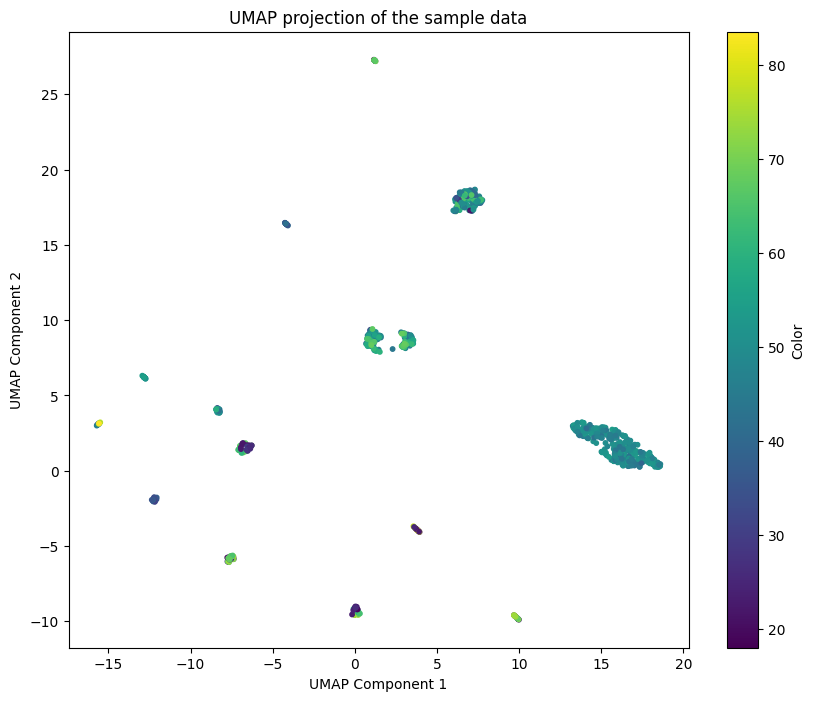

In [7]:
umap_projection(numeric_values, colors=training_data['Age'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


RangeIndex(start=0, stop=2, step=1)


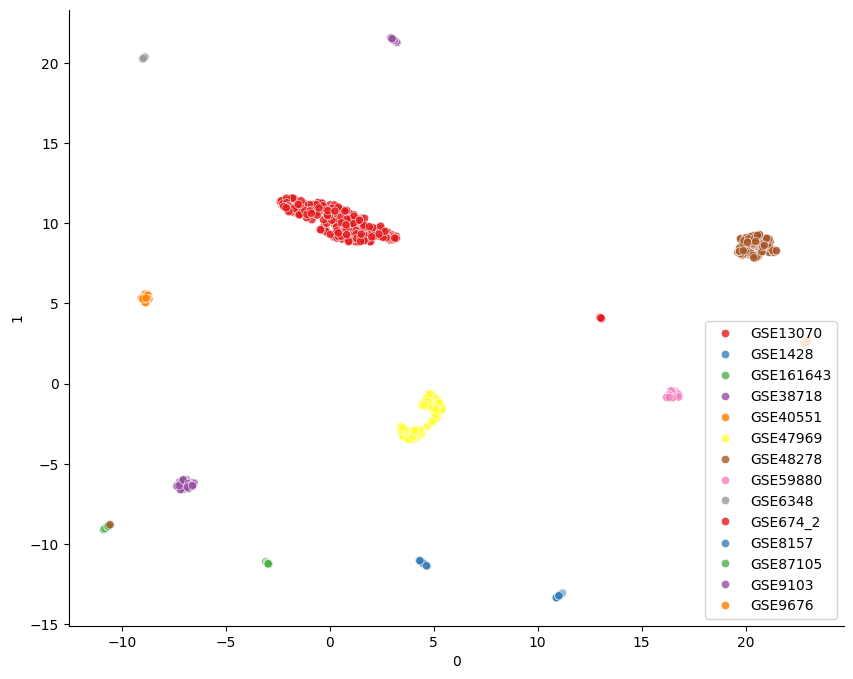

In [8]:
umap_projection(numeric_values, colors=training_data['Experiment'])

## Adjusted data
This is the same microarray data but after going throw the Combat batch correction

In [9]:
dataset_path_adjusted = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
training_data_adjusted=pd.read_csv(dataset_path_adjusted)
numeric_values_adjusted=m.remove_non_numeric_columns(training_data_adjusted)
numeric_values_adjusted.drop("Age", axis=1, inplace=True)


/tmp/ipykernel_23685/516243241.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  training_data_adjusted=pd.read_csv(dataset_path_adjusted)


### by Age

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


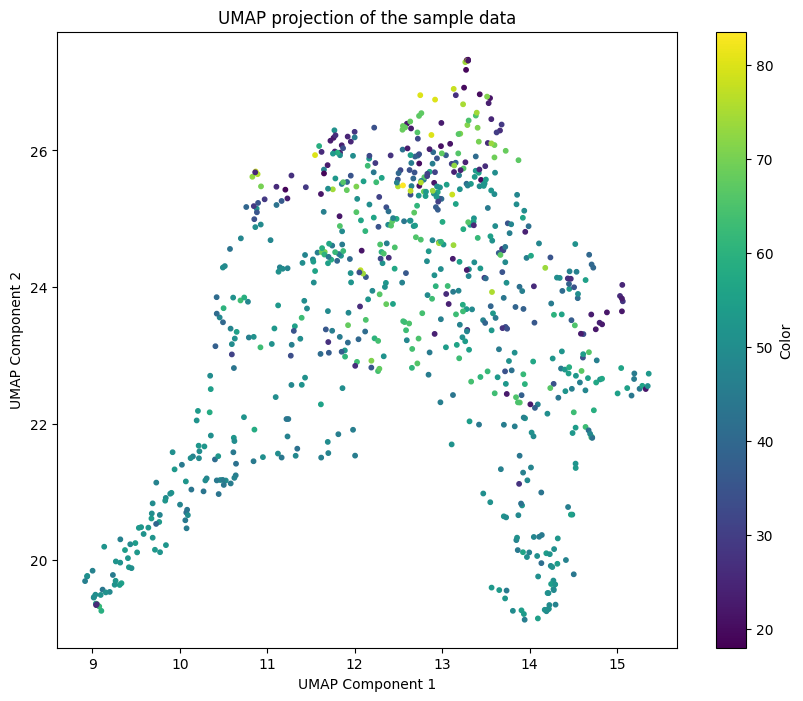

In [10]:
umap_projection(numeric_values_adjusted, colors=training_data_adjusted['Age'])

### by experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


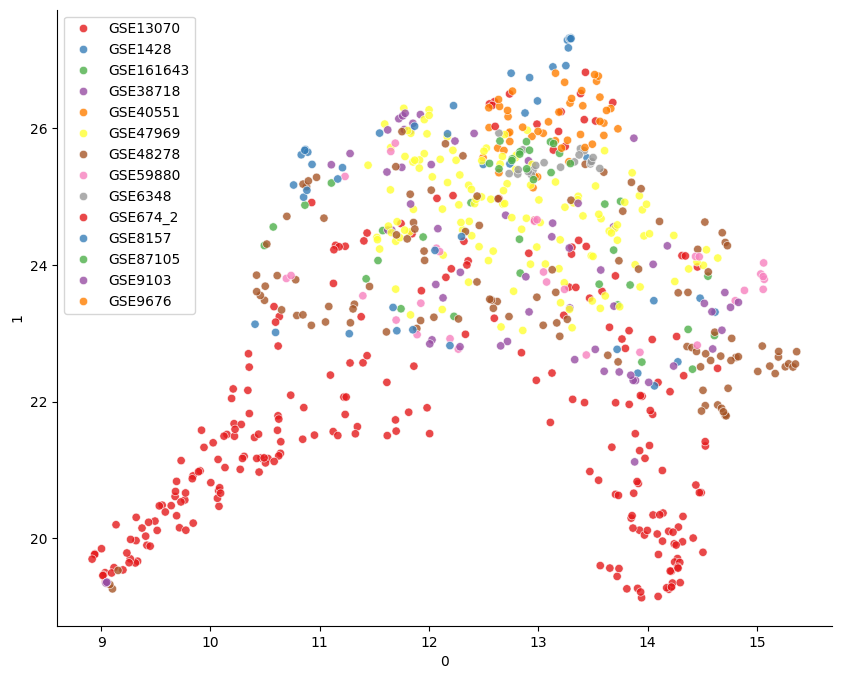

In [11]:
umap_projection(numeric_values_adjusted, colors=training_data_adjusted['Experiment'])

## After Z-score normalization

In [12]:
lasso_alpha = 0.9
m.train_data=training_data_adjusted
my_model = m.Model(training_data_adjusted)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data_adjusted, lasso_alpha=lasso_alpha, two_step=False)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values



### by experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


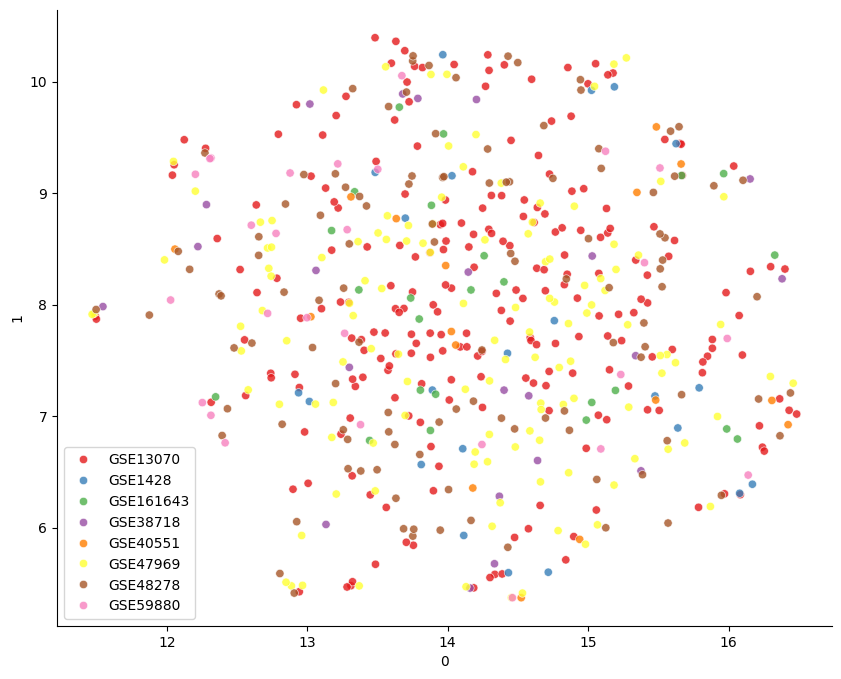

In [13]:
umap_projection(normalized_X_train, colors=training_data_adjusted['Experiment'])

### by age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


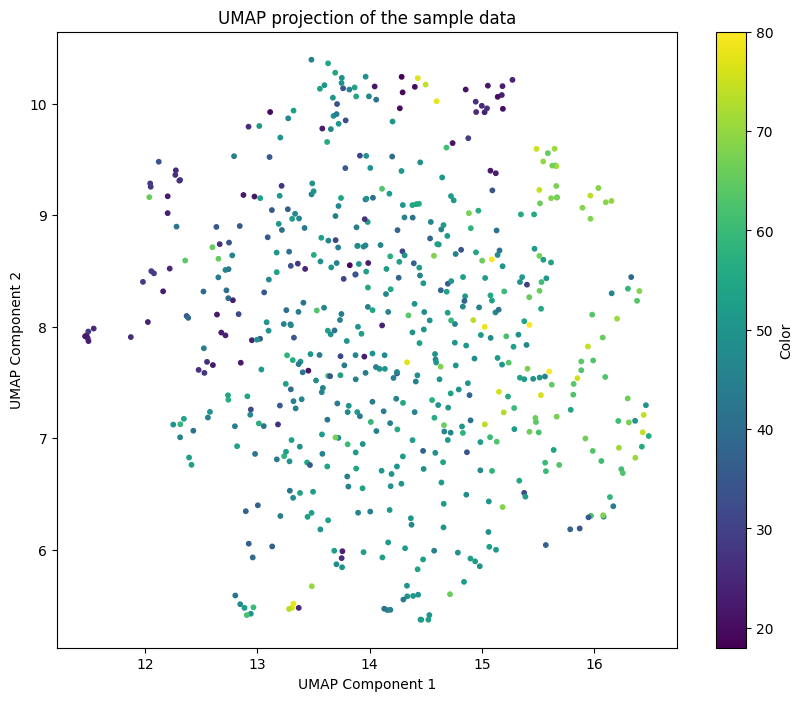

In [14]:
umap_projection(normalized_X_train, colors=feature_df['Age'])

### by age continuos

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


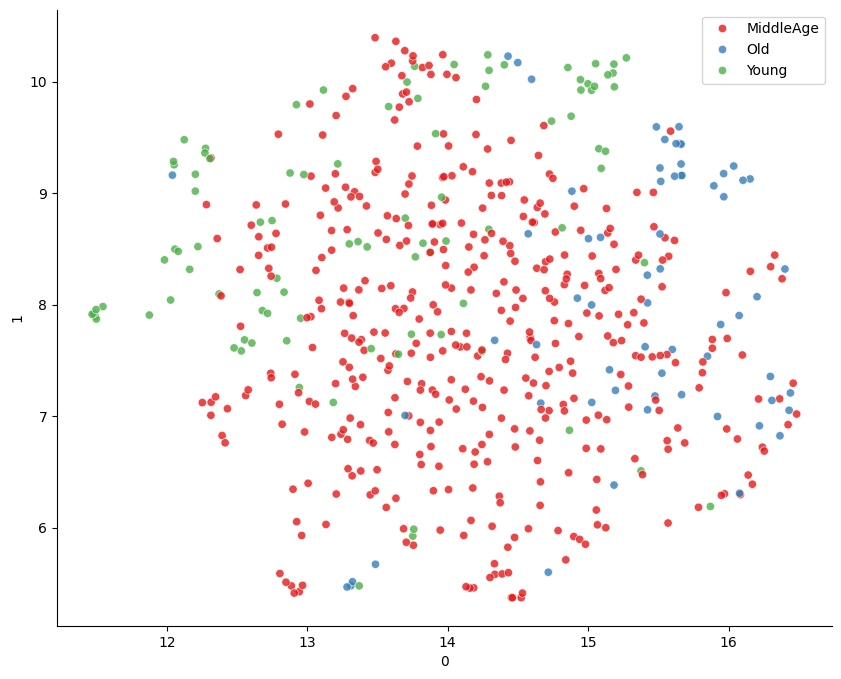

In [15]:
feature_df["Age_C"] = [map_to_category(age) for age in feature_df["Age"]] 
umap_projection(normalized_X_train, colors=feature_df['Age_C'])

## Two step normalization

In [16]:
lasso_alpha = 0.9
m.train_data=training_data_adjusted
my_model = m.Model(training_data_adjusted)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data_adjusted, lasso_alpha=lasso_alpha, two_step=True)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values



### by Experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


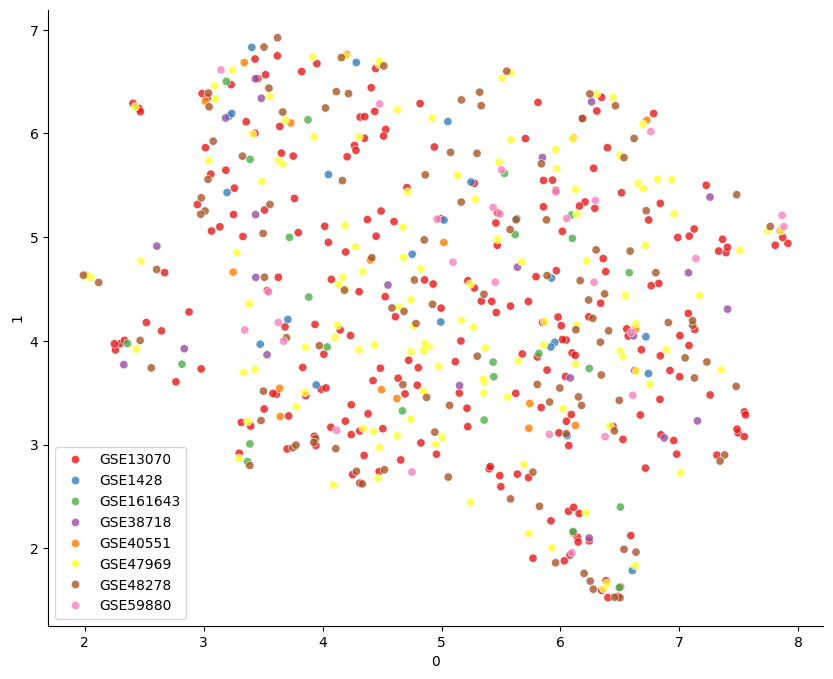

In [17]:
umap_projection(normalized_X_train, colors=training_data_adjusted['Experiment'])


### by age continus

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


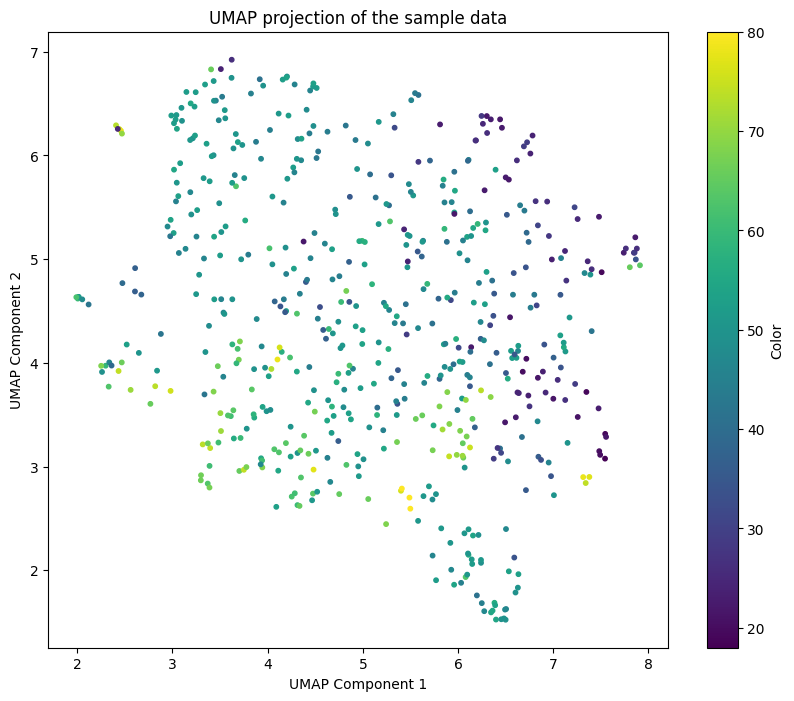

In [18]:
umap_projection(normalized_X_train, colors=feature_df['Age'])

### by age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


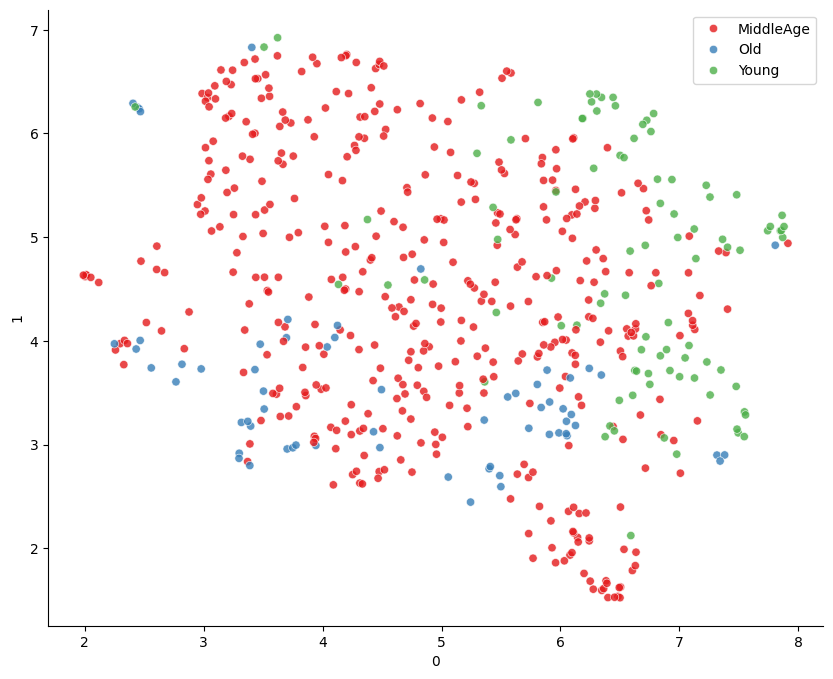

In [19]:
feature_df["Age"] = [map_to_category(age) for age in feature_df["Age"]]
umap_projection(normalized_X_train, colors=feature_df['Age'])

# RNAseq data

In [20]:
dataset_path = 'Data/RNAseq_All_abundances_unadjusted.csv'


training_data=pd.read_csv(dataset_path)
numeric_values=m.remove_non_numeric_columns(training_data)
numeric_values.drop("Age", axis=1, inplace=True)

## Unalterated data

### by age continues

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


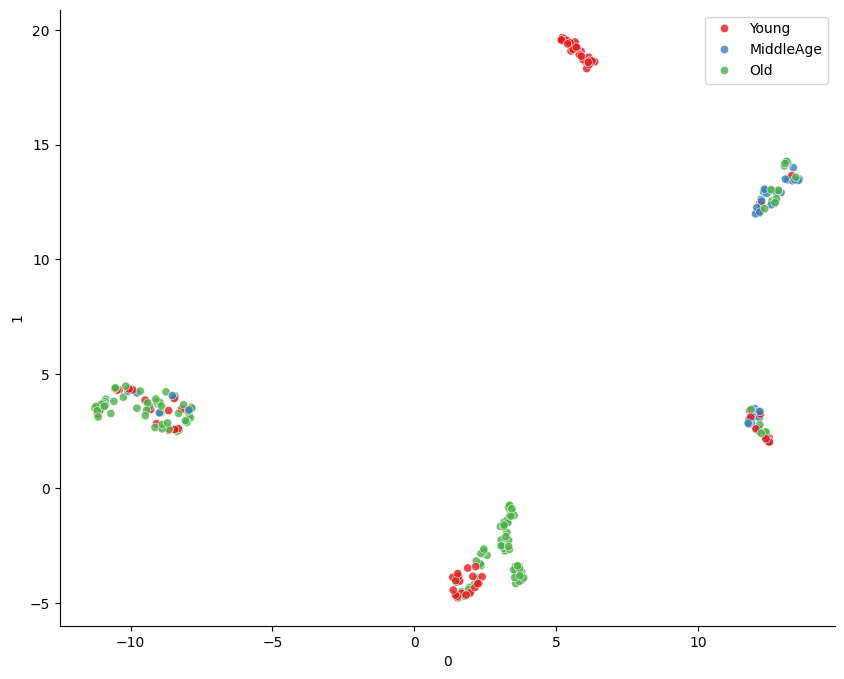

In [36]:
training_data["Age_c"] = [map_to_category(age) for age in training_data["Age"]] 
umap_projection(numeric_values, colors=training_data['Age_c'])

### by age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


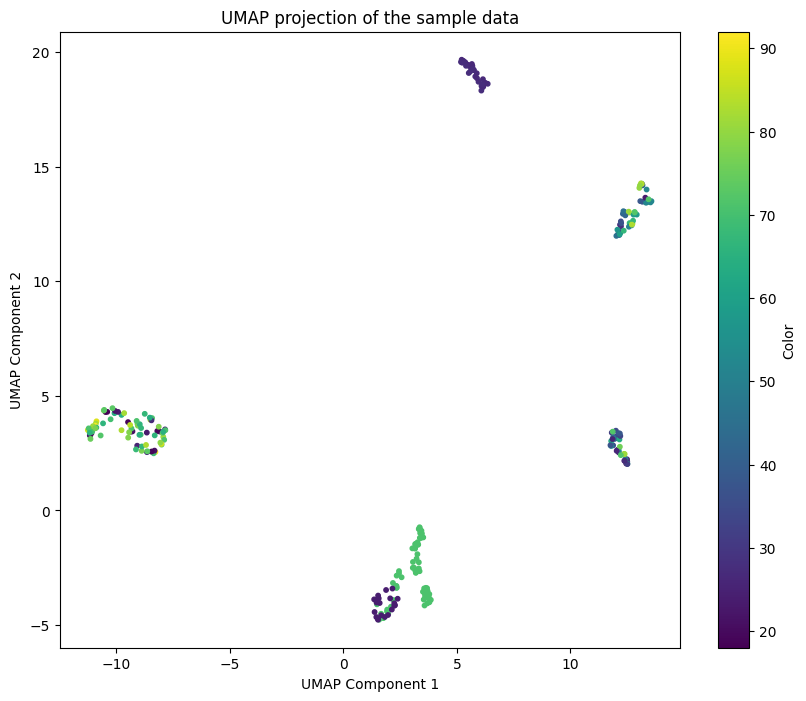

In [43]:

umap_projection(numeric_values, colors=training_data['Age'])

### by experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


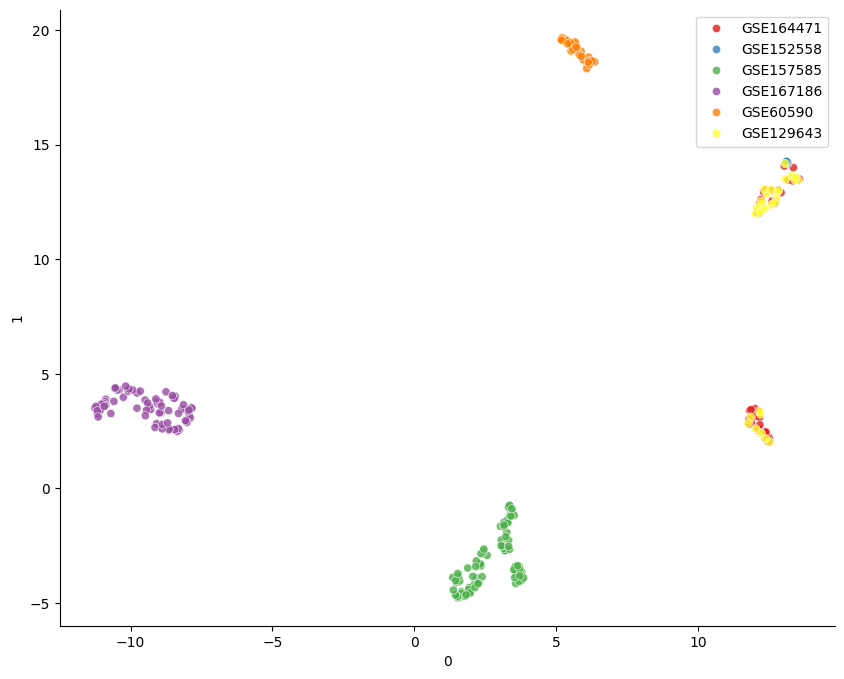

In [22]:
umap_projection(numeric_values, colors=training_data['Experiment'])

## Normalize

## Adjusted data

In [42]:
dataset_path_adjusted = '/home/karen/Documents/phd/Data/Batch_corrected/RNAs_z_Combat.csv'

training_data_adjusted=pd.read_csv(dataset_path_adjusted)
numeric_values_adjusted=m.remove_non_numeric_columns(training_data_adjusted)
numeric_values_adjusted.drop("Age", axis=1, inplace=True)

In [43]:
training_data_adjusted

,Sample,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,...,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1,Experiment,Age
0,SRR13388732,-0.025109,-0.028258,-0.005872,-0.026729,-0.026472,-0.027634,-0.020870,-0.022772,-0.022661,...,-0.028169,-0.028120,-0.028027,-0.027546,-0.028289,-0.028272,-0.024716,-0.028265,GSE164471,23.0
1,SRR13388733,-0.026260,-0.033508,-0.004524,-0.028312,-0.031995,-0.032750,-0.016343,-0.026733,-0.023806,...,-0.033510,-0.033522,-0.033509,-0.032635,-0.033518,-0.033482,-0.020903,-0.032705,GSE164471,28.0
2,SRR13388734,-0.030608,-0.037952,-0.002987,-0.034886,-0.029932,-0.038745,-0.014741,-0.030696,-0.027022,...,-0.038155,-0.039709,-0.039524,-0.038657,-0.039251,-0.039648,-0.036926,-0.038901,GSE164471,31.0
3,SRR13388735,-0.021728,-0.024309,-0.004225,-0.022910,-0.023840,-0.024011,-0.019799,-0.021443,-0.022365,...,-0.024390,-0.024440,-0.024351,-0.023795,-0.024435,-0.024431,-0.021008,-0.024095,GSE164471,31.0
4,SRR13388736,-0.019503,-0.034629,-0.004944,-0.031244,-0.026323,-0.034354,-0.021341,-0.015501,-0.017102,...,-0.034285,-0.033820,-0.034226,-0.033922,-0.035173,-0.035132,-0.031649,-0.034687,GSE164471,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,SRR8882198,-0.019750,-0.021331,-0.005098,-0.020260,-0.021419,-0.020946,-0.018419,-0.019666,-0.019176,...,-0.021333,-0.021377,-0.021335,-0.020852,-0.021341,-0.021372,-0.020049,-0.021263,GSE129643,27.0
266,SRR8882200,-0.017618,-0.019354,-0.003957,-0.018234,-0.019187,-0.019024,-0.016646,-0.017455,-0.018713,...,-0.019334,-0.019429,-0.019360,-0.018994,-0.019396,-0.019424,-0.018100,-0.019367,GSE129643,33.0
267,SRR8882202,-0.018818,-0.020237,-0.003773,-0.018901,-0.020455,-0.019962,-0.016610,-0.018502,-0.018296,...,-0.020258,-0.020326,-0.020308,-0.019834,-0.020319,-0.020318,-0.018674,-0.020279,GSE129643,37.0
268,SRR8882203,-0.017649,-0.018998,-0.003477,-0.017604,-0.019472,-0.018760,-0.016018,-0.017490,-0.017853,...,-0.018996,-0.019074,-0.019036,-0.018651,-0.019067,-0.019071,-0.017318,-0.019013,GSE129643,38.0


### by age continus

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


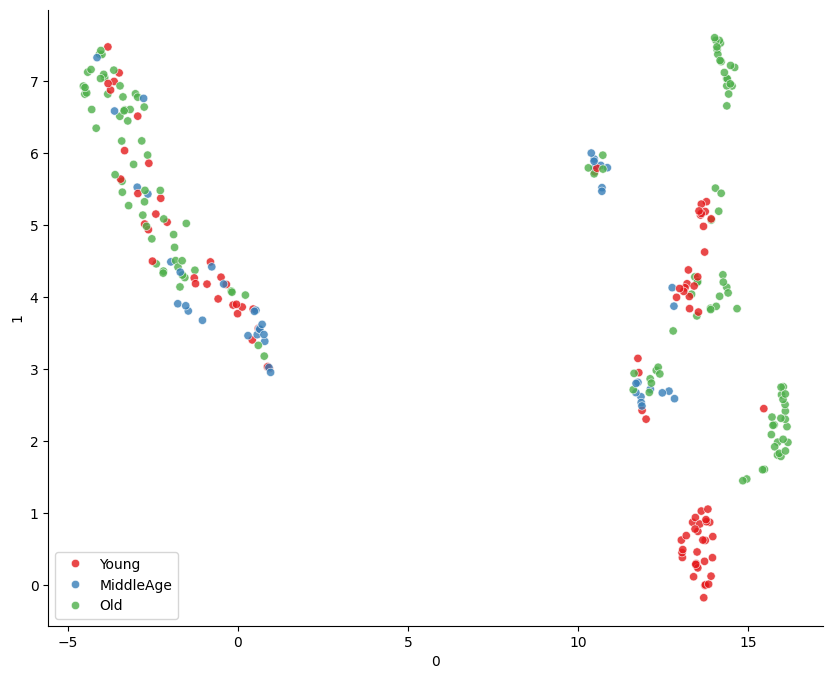

In [44]:
training_data_adjusted["Age_c"] = [map_to_category(age) for age in training_data_adjusted["Age"]] 
umap_projection(numeric_values_adjusted, colors=training_data_adjusted['Age_c'])

### by age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


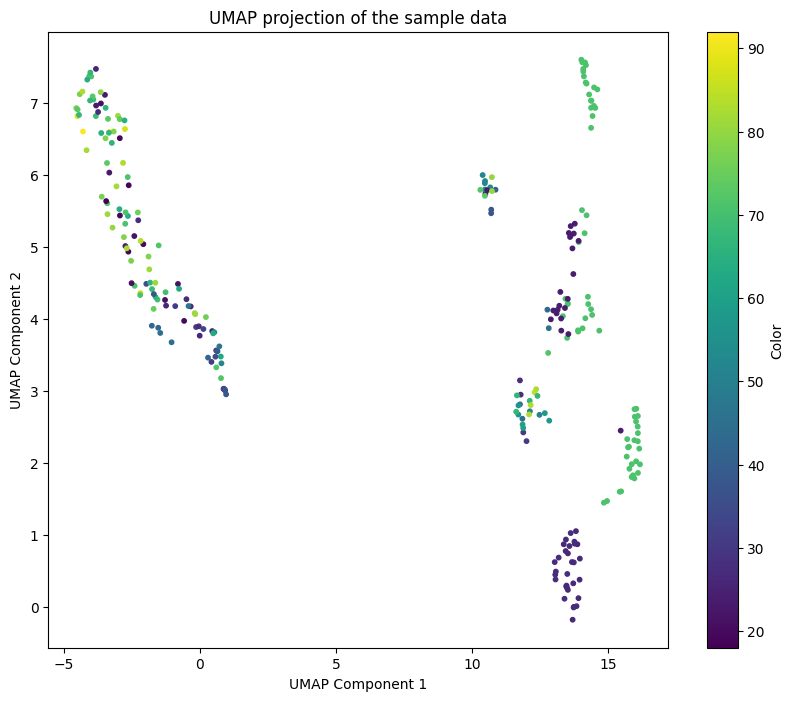

In [45]:
umap_projection(numeric_values_adjusted, colors=training_data_adjusted['Age'])

### by experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


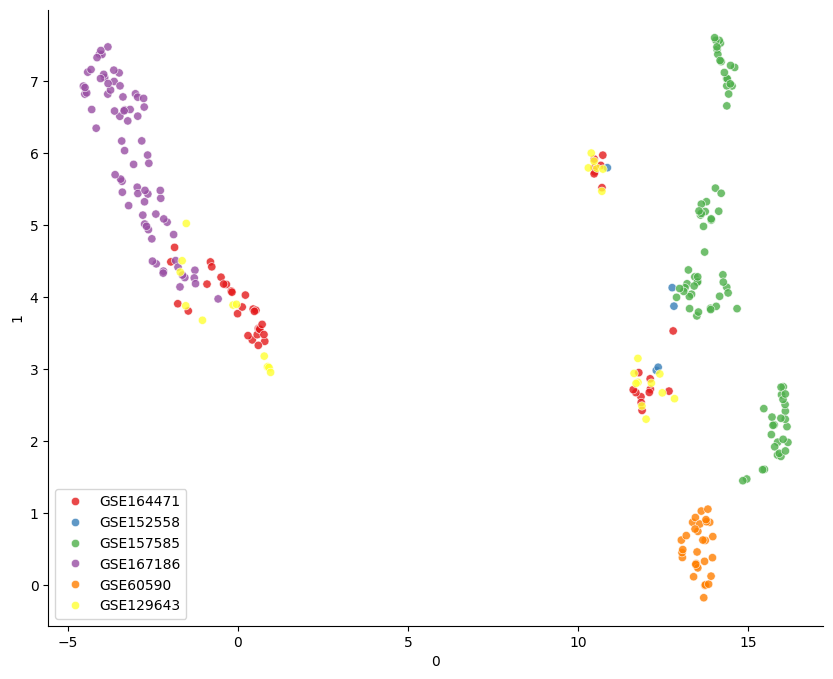

In [46]:
umap_projection(numeric_values_adjusted, colors=training_data_adjusted['Experiment'])

## Batch corrected X Ridge

In [47]:
ridge_csv = pd.read_csv('/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAs_z_Combat_8_Ridge_seq_RIDGE_regressor_genes.csv')
ridge_csv.columns=['Gene', 'Coef']

In [55]:
ridge_csv.columns=['Gene', 'Coef']
ridge_csv = ridge_csv[ridge_csv['Coef']>0.5]
len(ridge_csv)

35

In [56]:
training_data_adjusted_ridge = m.remove_non_numeric_columns(training_data_adjusted)
training_data_adjusted_ridge.head()

training_data_adjusted_ridge.drop(columns=['Age'], inplace=True)


In [57]:
# Multiply the columns on training_data_adjusted_ridge with the values on ridge_csv if the value exist, if not, set it to 0
for column in training_data_adjusted_ridge.columns:
    if column in ridge_csv['Gene'].values:
        training_data_adjusted_ridge[column] = training_data_adjusted_ridge[column] * ridge_csv[ridge_csv['Gene']==column]['Coef'].values[0]
    else:
        training_data_adjusted_ridge[column] = 0
training_data_adjusted_ridge.head()

,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
#remove columns that have all values equal to 0
training_data_adjusted_ridge = training_data_adjusted_ridge.loc[:, (training_data_adjusted_ridge != 0).any(axis=0)]
training_data_adjusted_ridge.head()

,ENSG00000069275.12,ENSG00000082397.17,ENSG00000085231.13,ENSG00000089101.17,ENSG00000101745.16,ENSG00000101892.11,ENSG00000111640.14,ENSG00000112031.15,ENSG00000112562.18,ENSG00000123095.5,...,ENSG00000182108.10,ENSG00000185551.14,ENSG00000185760.15,ENSG00000188176.11,ENSG00000199455.1,ENSG00000222427.1,ENSG00000227097.5,ENSG00000238391.1,ENSG00000270388.1,ENSG00000277654.5
0,0.195069,-0.024210,-0.009555,-0.028441,0.065899,-0.070592,0.172143,-0.006924,-0.006685,0.042568,...,-0.013017,-0.011763,-0.016760,0.004914,0.005257,-0.019453,0.032531,0.034175,-0.021310,-0.036982
1,0.194112,-0.029379,-0.011283,-0.032997,0.057525,-0.078317,0.209182,0.004352,-0.007834,0.038515,...,-0.015546,-0.012275,0.002215,0.003983,-0.019630,-0.021901,0.038297,0.014601,-0.024297,-0.043970
2,0.192697,-0.028769,-0.012741,-0.028210,0.029425,-0.157040,1.820262,0.000238,-0.004970,0.033203,...,-0.013195,-0.014995,-0.012816,0.013833,-0.022540,-0.024797,0.039661,0.013872,-0.026137,-0.039936
3,0.196017,-0.020527,-0.007213,-0.023231,0.005579,-0.099403,0.198093,-0.007507,-0.004955,0.046090,...,-0.011018,-0.009953,-0.015131,0.005310,-0.015360,-0.017648,0.036884,-0.012475,-0.000094,-0.030567
4,0.194405,-0.021030,-0.009270,-0.021980,0.022656,-0.076493,0.493606,-0.004220,-0.005202,0.036921,...,-0.014386,-0.014452,-0.004338,0.005652,0.023335,-0.022676,0.031240,0.012330,0.021407,-0.042901


### by age continuous

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


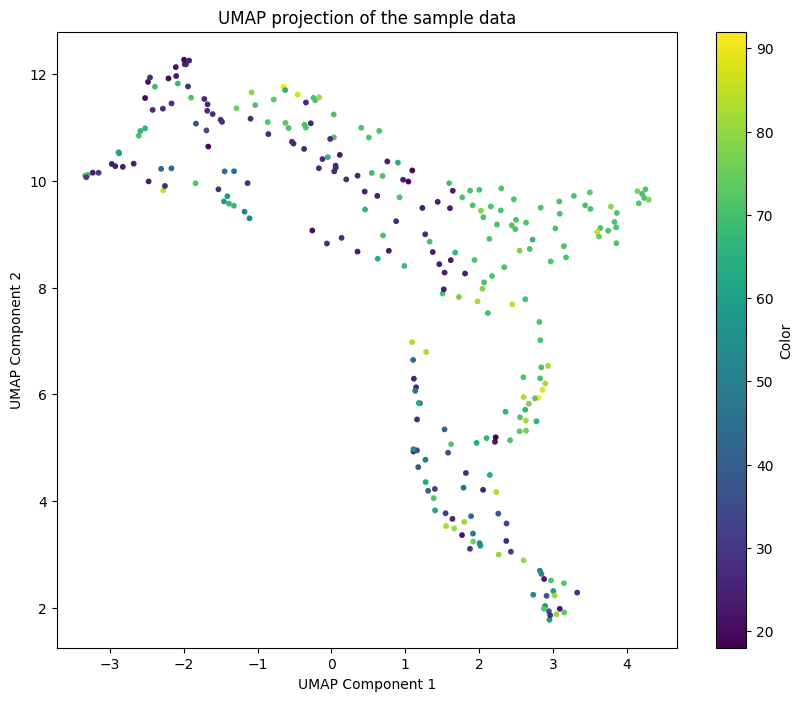

In [59]:
umap_projection(training_data_adjusted_ridge, colors=training_data_adjusted['Age'])

### by Experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


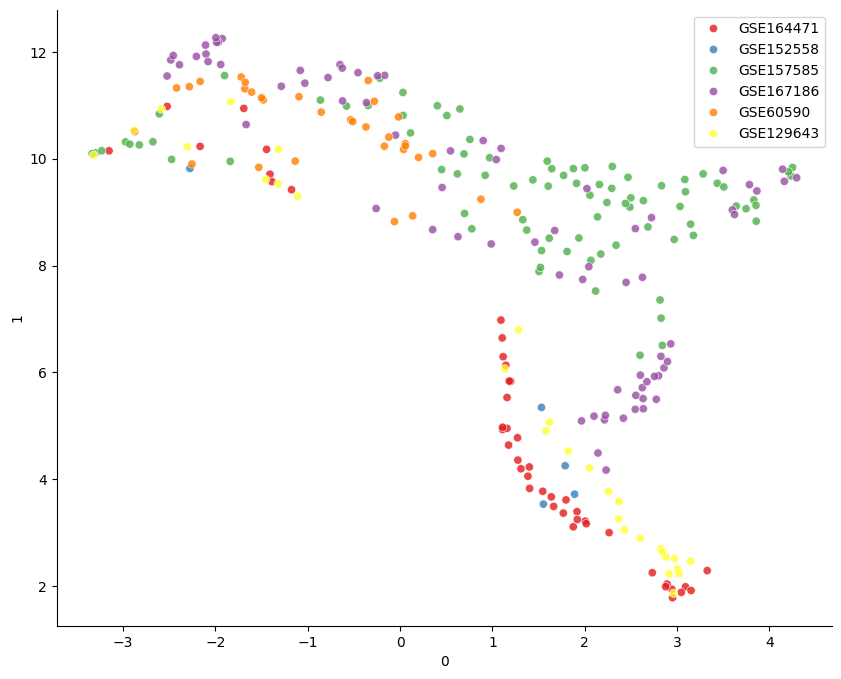

In [60]:
umap_projection(numeric_values_adjusted, colors=training_data_adjusted['Experiment'])

### By age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


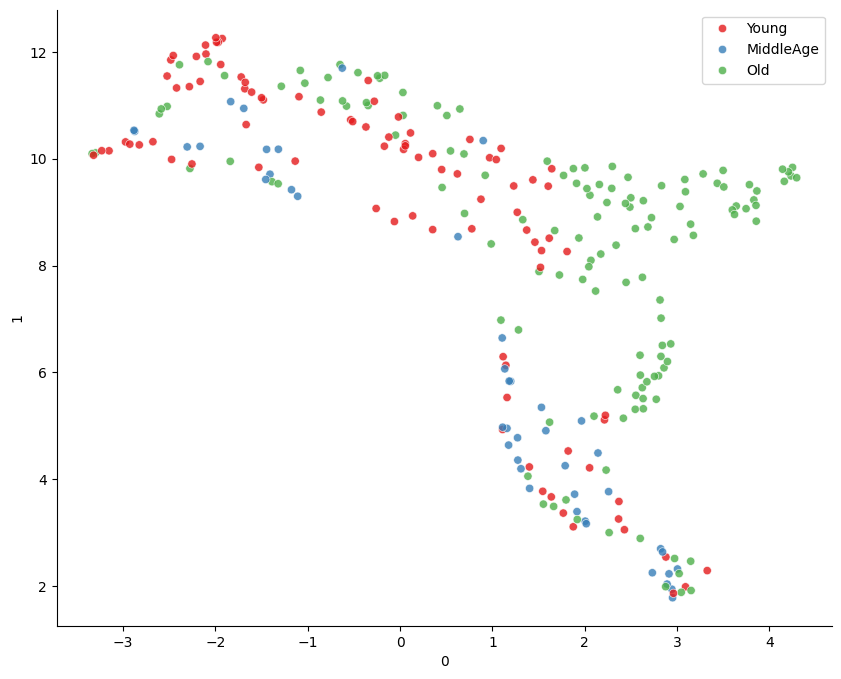

In [61]:
training_data_adjusted_ridge["Age_c"] = [map_to_category(age) for age in training_data_adjusted["Age"]] 
umap_projection(training_data_adjusted_ridge.drop(columns="Age_c"), colors=training_data_adjusted_ridge['Age_c'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


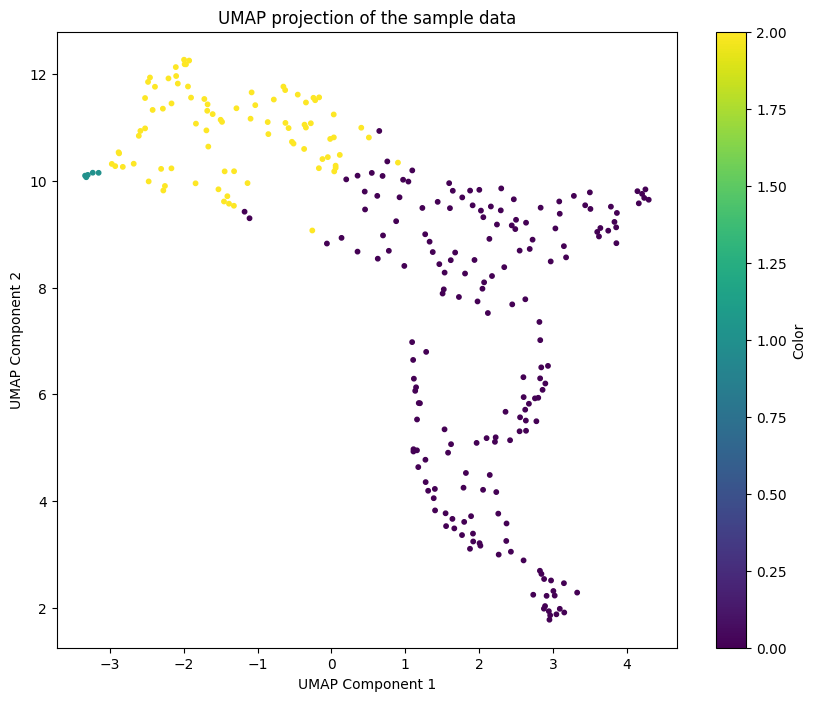

In [63]:
## CLuster training_data_adjusted_ridge.drop(columns="Age_c") by Age_C
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(training_data_adjusted_ridge.drop(columns="Age_c"))
training_data_adjusted_ridge["Cluster"] = kmeans.labels_
training_data_adjusted_ridge["Age_c"] = training_data_adjusted["Age_c"]
umap_projection(training_data_adjusted_ridge.drop(columns=["Age_c", "Cluster"]), colors=training_data_adjusted_ridge['Cluster'])



In [70]:
training_data_adjusted_ridge["together"] = training_data_adjusted_ridge["Cluster"].astype(str) + training_data_adjusted["Experiment"]
training_data_adjusted_ridge["together"].value_counts()


together
0GSE157585    64
0GSE167186    47
0GSE164471    38
2GSE167186    28
2GSE60590     25
0GSE129643    21
2GSE157585    17
2GSE129643     7
2GSE164471     7
0GSE60590      6
0GSE152558     4
1GSE157585     3
1GSE164471     1
2GSE152558     1
1GSE129643     1
Name: count, dtype: int64

## Shape values

In [88]:
cat_csv = pd.read_csv('/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAseq_shap.csv')
cat_csv.columns=['Gene', 'Coef']
training_data_adjusted_cat = m.remove_non_numeric_columns(training_data_adjusted)
training_data_adjusted_cat.head()

training_data_adjusted_cat.drop(columns=['Age'], inplace=True)



,ENSG00000000003.14,ENSG00000000005.5,ENSG00000000419.12,ENSG00000000457.13,ENSG00000000460.16,ENSG00000000938.12,ENSG00000000971.15,ENSG00000001036.13,ENSG00000001084.11,ENSG00000001167.14,...,ENSG00000285458.1,ENSG00000285470.1,ENSG00000285471.1,ENSG00000285472.1,ENSG00000285476.1,ENSG00000285480.1,ENSG00000285491.1,ENSG00000285505.1,ENSG00000285508.1,ENSG00000285509.1
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [91]:
cat_csv = cat_csv[cat_csv['Coef']>0.5]
len(cat_csv)

53

In [92]:

for column in training_data_adjusted_cat.columns:
    if column in cat_csv['Gene'].values:
        training_data_adjusted_cat[column] = training_data_adjusted_cat[column] * cat_csv[cat_csv['Gene']==column]['Coef'].values[0]
    else:
        training_data_adjusted_cat[column] = 0
training_data_adjusted_cat.head()

,ENSG00000004866.20,ENSG00000010256.10,ENSG00000012061.15,ENSG00000015676.17,ENSG00000020577.13,ENSG00000022840.15,ENSG00000023330.14,ENSG00000036672.15,ENSG00000043093.13,ENSG00000054267.21,...,ENSG00000271687.1,ENSG00000272134.1,ENSG00000272253.1,ENSG00000273173.5,ENSG00000274855.1,ENSG00000275387.1,ENSG00000277203.1,ENSG00000277252.1,ENSG00000283426.1,ENSG00000285437.1
0,0,0,0,0.000984,0,0,0,0,0,0,...,0,0,0,0,0,0,-0.037678,-0.038001,0,0
1,0,0,0,0.001601,0,0,0,0,0,0,...,0,0,0,0,0,0,-0.049592,-0.044270,0,0
2,0,0,0,0.001012,0,0,0,0,0,0,...,0,0,0,0,0,0,-0.063040,-0.051689,0,0
3,0,0,0,0.001528,0,0,0,0,0,0,...,0,0,0,0,0,0,-0.038149,-0.033380,0,0
4,0,0,0,0.000882,0,0,0,0,0,0,...,0,0,0,0,0,0,-0.058358,-0.046255,0,0


In [93]:
#remove columns that have all values equal to 0
training_data_adjusted_cat = training_data_adjusted_cat.loc[:, (training_data_adjusted_cat != 0).any(axis=0)]
training_data_adjusted_cat.head()

,ENSG00000015676.17,ENSG00000065518.7,ENSG00000089101.17,ENSG00000100603.13,ENSG00000101204.16,ENSG00000107147.12,ENSG00000110799.13,ENSG00000112992.16,ENSG00000114023.15,ENSG00000118729.11,...,ENSG00000225972.1,ENSG00000227097.5,ENSG00000232177.1,ENSG00000247627.2,ENSG00000249072.1,ENSG00000249119.1,ENSG00000260908.1,ENSG00000270672.1,ENSG00000277203.1,ENSG00000277252.1
0,0.000984,-0.004670,-0.217406,-0.000823,-0.010715,-0.005854,-0.003761,0.028696,0.020710,0.009047,...,0.202818,0.010936,-0.036271,-0.004673,-0.009622,-0.058693,-0.013776,-0.932089,-0.037678,-0.038001
1,0.001601,-0.002880,-0.252227,0.001821,-0.012512,-0.007740,-0.002665,0.084658,0.033342,0.023719,...,0.024873,0.012875,-0.043465,-0.009477,-0.017983,-0.077783,-0.015779,3.220578,-0.049592,-0.044270
2,0.001012,-0.001217,-0.215635,0.006206,-0.014584,0.028200,-0.005287,0.038707,0.040169,0.017990,...,0.687398,0.013333,-0.043470,-0.002538,-0.016643,-0.075029,-0.018023,-0.207663,-0.063040,-0.051689
3,0.001528,0.001147,-0.177577,0.000705,-0.009470,-0.004487,-0.002959,0.027006,0.022440,0.010995,...,1.201385,0.012400,0.030166,0.071504,0.003572,-0.051502,-0.009054,1.397963,-0.038149,-0.033380
4,0.000882,0.045539,-0.168013,0.003360,0.000702,-0.008264,-0.002908,0.037735,0.032323,0.011057,...,0.409346,0.010502,0.021628,-0.005183,-0.015880,-0.080802,0.029126,0.058133,-0.058358,-0.046255


/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


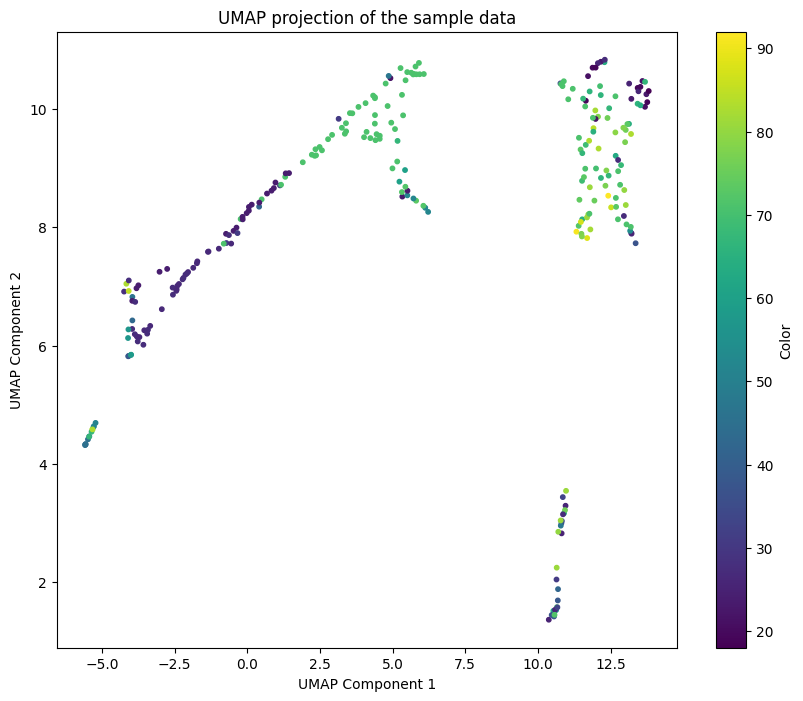

In [94]:

umap_projection(training_data_adjusted_cat, colors=training_data_adjusted['Age'].values)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


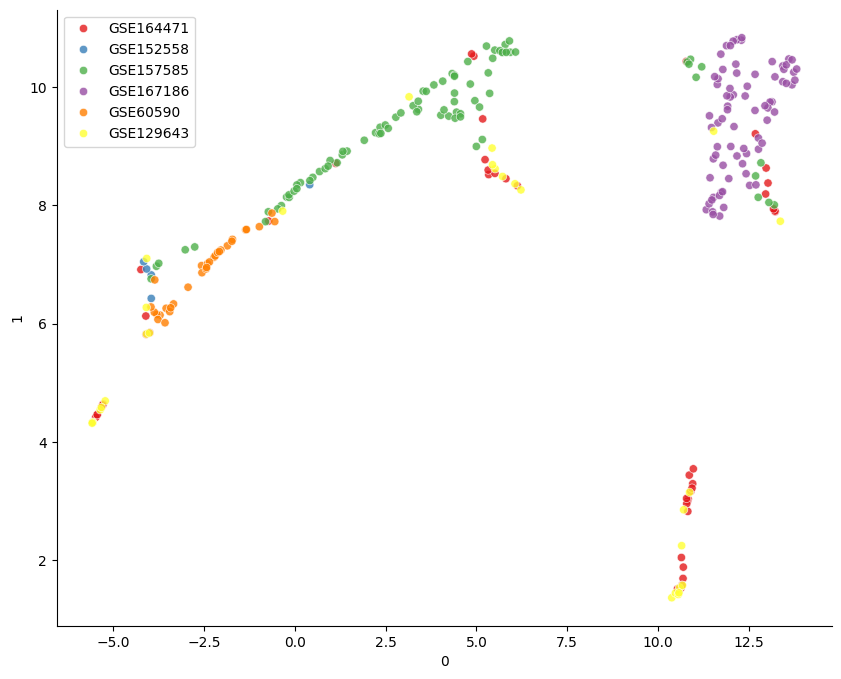

In [95]:
umap_projection(training_data_adjusted_cat, colors=training_data_adjusted['Experiment'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


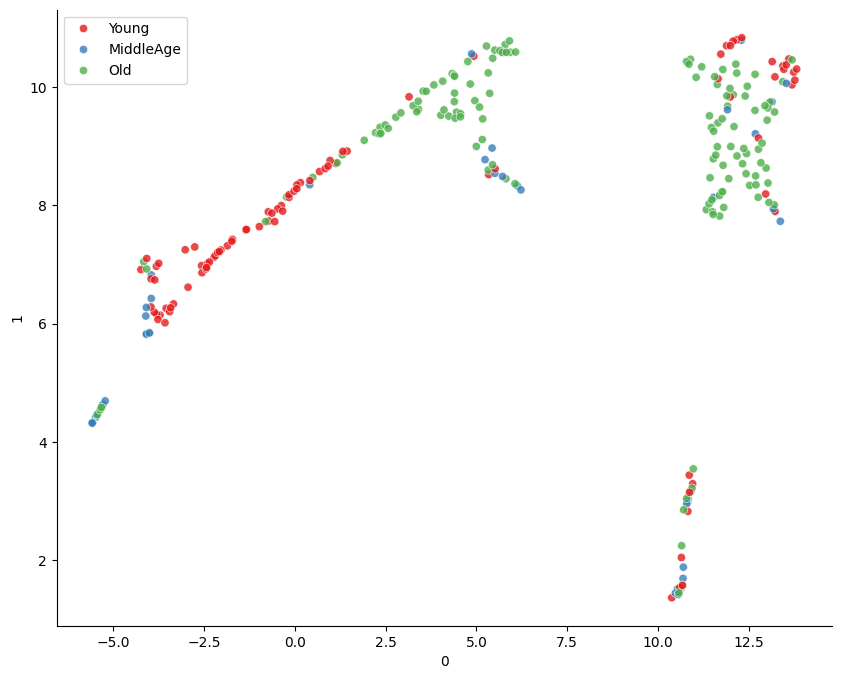

In [96]:
training_data_adjusted_cat["Age_c"] = [map_to_category(age) for age in training_data_adjusted["Age"]] 
umap_projection(training_data_adjusted_cat.drop(columns="Age_c"), colors=training_data_adjusted_cat['Age_c'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


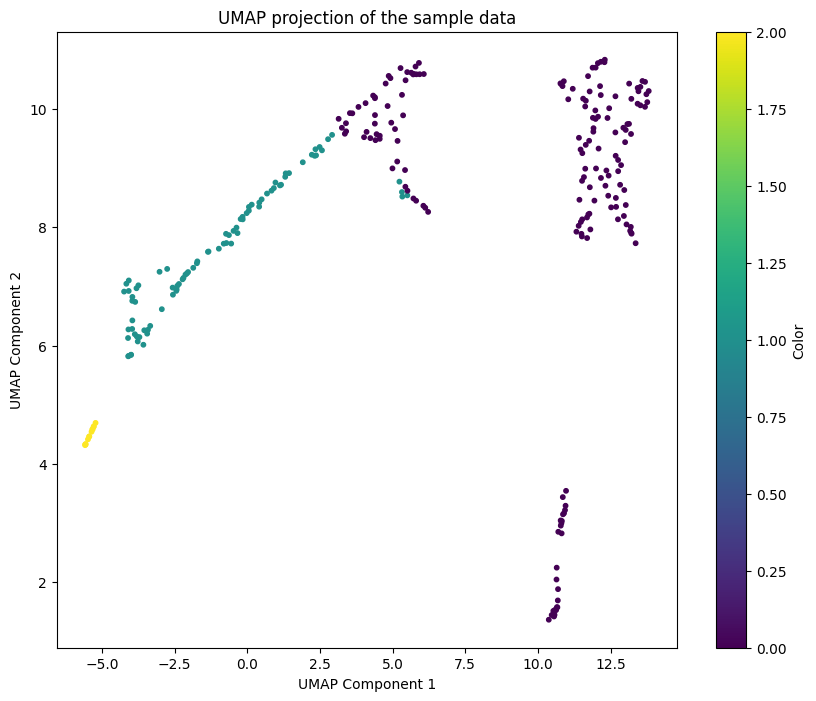

In [97]:
## CLuster training_data_adjusted_cat.drop(columns="Age_c") by Age_C
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0).fit(training_data_adjusted_cat.drop(columns="Age_c"))
training_data_adjusted_cat["Cluster"] = kmeans.labels_
training_data_adjusted_cat["Age_c"] = training_data_adjusted["Age_c"]
umap_projection(training_data_adjusted_cat.drop(columns=["Age_c", "Cluster"]), colors=training_data_adjusted_cat['Cluster'])



In [103]:
# get MCC of the cluster with Age_c
from sklearn.metrics import matthews_corrcoef
map_to_category = {'MiddleAge': 2, 'Old': 0, 'Young': 1}
mcc = matthews_corrcoef(training_data_adjusted_cat["Cluster"], training_data_adjusted_cat["Age_c"].map(map_to_category))
confussion_matrix_age = pd.crosstab(training_data_adjusted_cat["Cluster"], training_data_adjusted_cat["Age_c"].map(map_to_category))
confussion_matrix_age

Age_c,0,1,2
Cluster,,,
0,114,33,24
1,17,58,11
2,4,0,9


In [104]:
mcc

0.4340424301411498

## Z-score normalization

In [49]:
lasso_alpha = 0.9
m.train_data=training_data_adjusted
my_model = m.Model(training_data_adjusted)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data_adjusted, lasso_alpha=lasso_alpha, two_step=False)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values

### by Age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


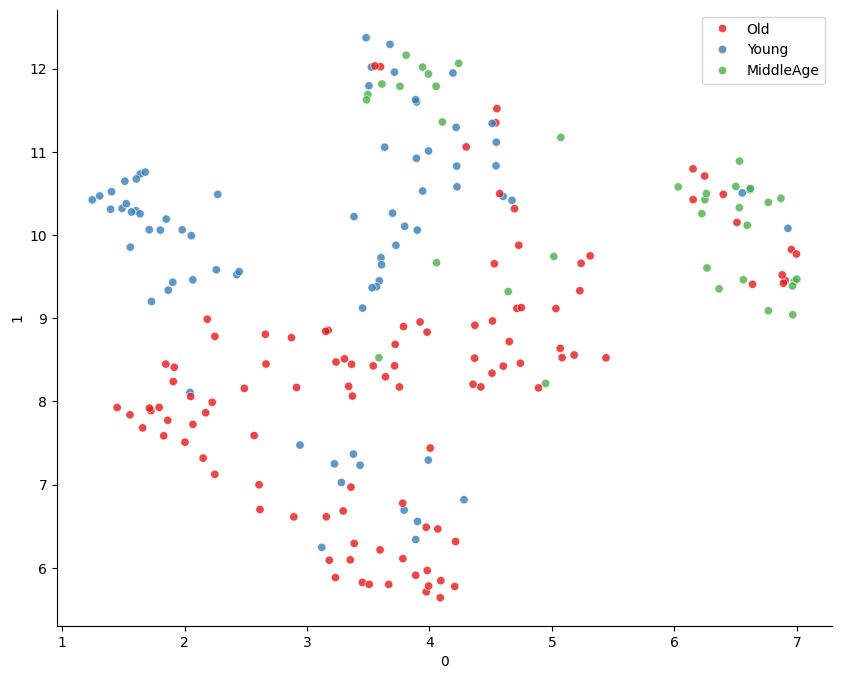

In [50]:


feature_df["Age_C"] = [map_to_category(age) for age in feature_df["Age"]] 
umap_projection(normalized_X_train, colors=feature_df['Age_C'])

### by age continuous

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


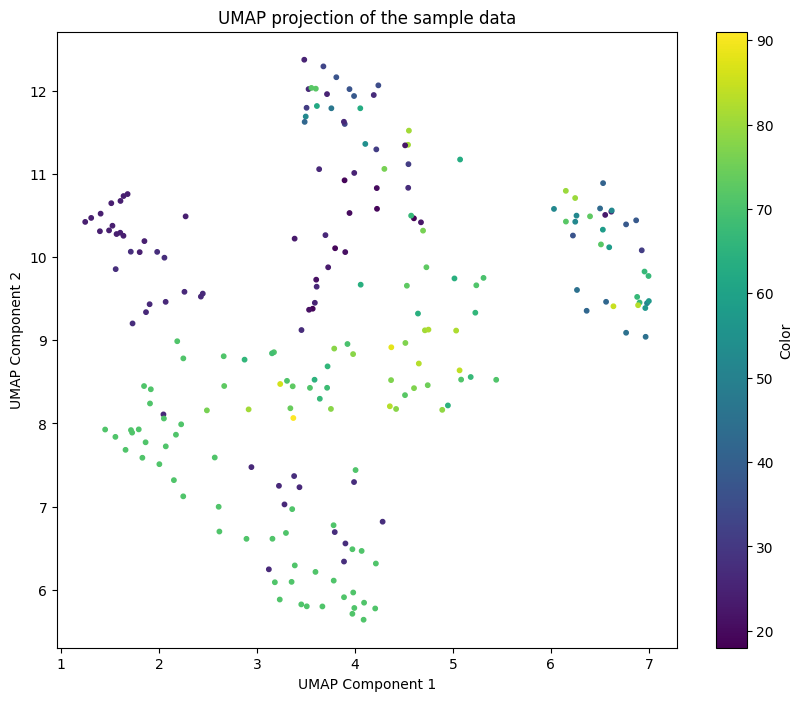

In [51]:
umap_projection(normalized_X_train, colors=feature_df['Age'])

### by experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


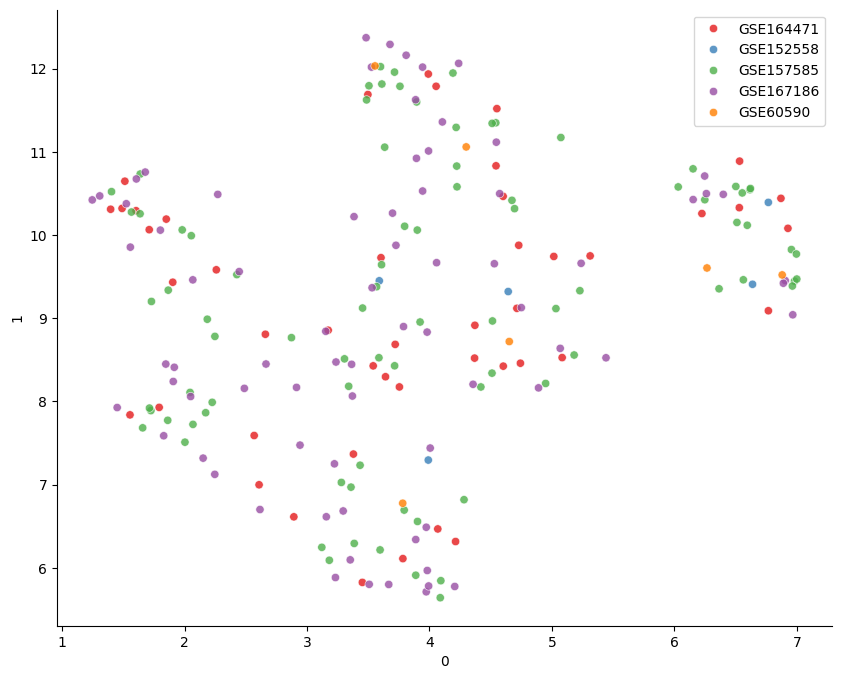

In [52]:
umap_projection(normalized_X_train, colors=training_data_adjusted['Experiment'])

## Two steps normalization

In [53]:
lasso_alpha = 0.9
m.train_data=training_data_adjusted
my_model = m.Model(training_data_adjusted)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data_adjusted, lasso_alpha=lasso_alpha, two_step=True)


feature_df = pd.DataFrame(normalized_X_train)
feature_df = feature_df.dropna()
feature_df
feature_df["Age"]= my_model.y_train.values



### by Age discrete

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


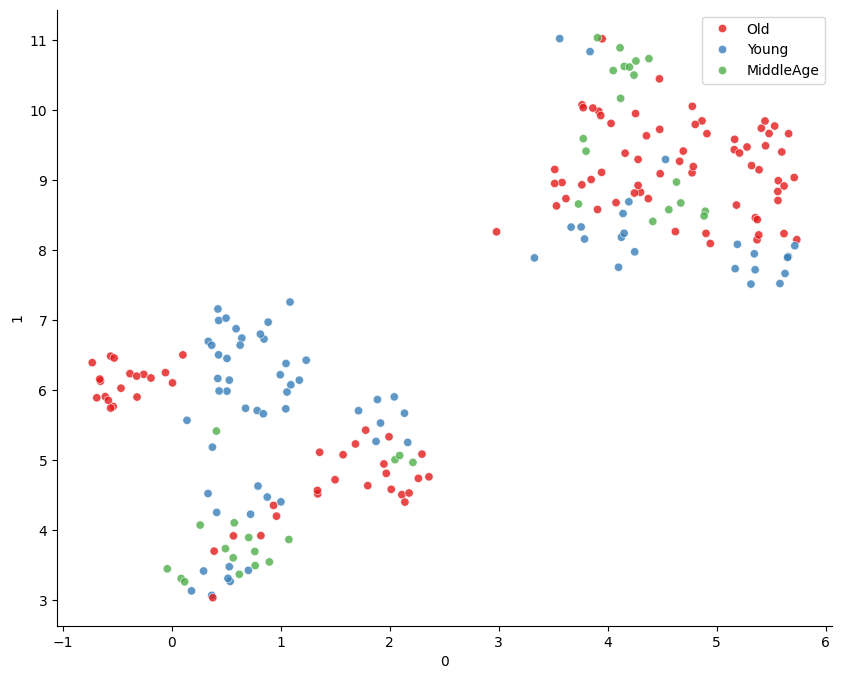

In [54]:
feature_df["Age_c"] = [map_to_category(age) for age in feature_df["Age"]]
umap_projection(normalized_X_train, colors=feature_df['Age_c'])

### by age continuous

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


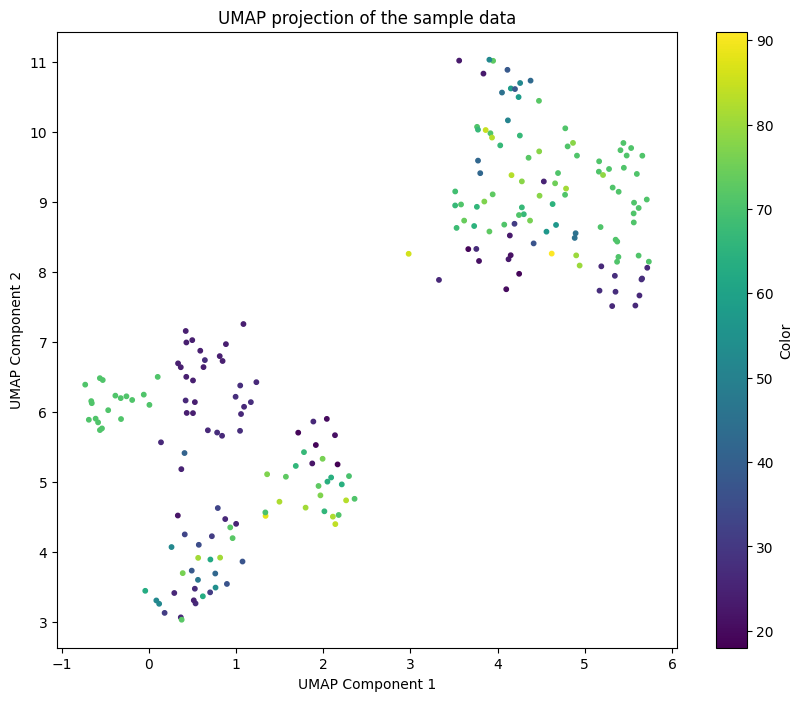

In [55]:
umap_projection(normalized_X_train, colors=feature_df['Age'])


### by experiment

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


RangeIndex(start=0, stop=2, step=1)


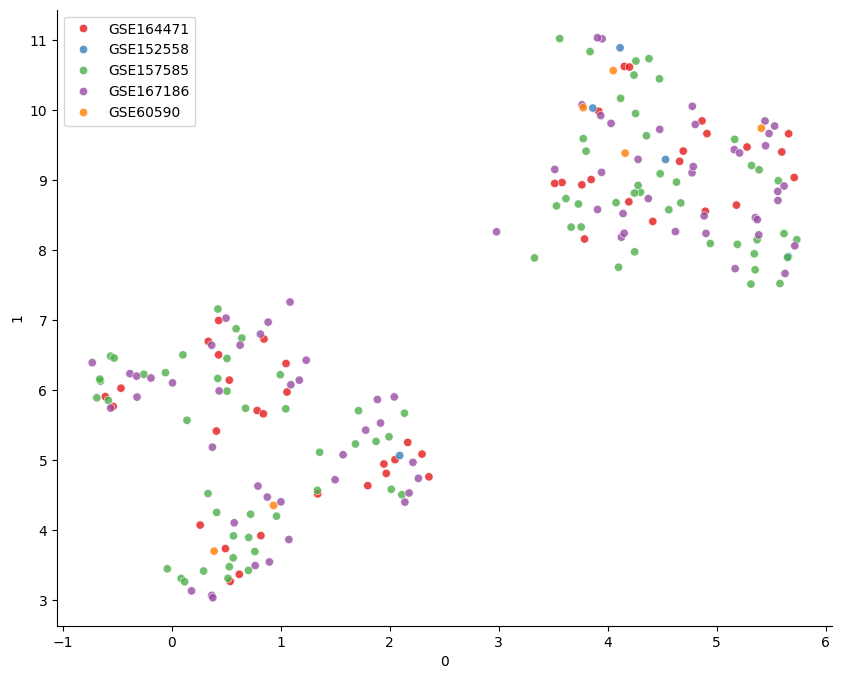

In [56]:
umap_projection(normalized_X_train, colors=training_data_adjusted['Experiment'])
